In [1]:
import numpy as np
import matplotlib.pyplot as plt
from config import STIMULI, PRIORS, SPIKE_COUNTS

In [2]:
def gaussian_likelihood(counts, mu, sigma, scale=0.15):
    return scale * np.exp(-0.5 * ((counts - mu) / sigma) ** 2)

In [3]:
# ------------------------------------------------------------
# Provided likelihood curves
# ------------------------------------------------------------
lik_left = gaussian_likelihood(SPIKE_COUNTS, mu=5, sigma=3)
lik_forward = gaussian_likelihood(SPIKE_COUNTS, mu=10, sigma=3)
lik_right = gaussian_likelihood(SPIKE_COUNTS, mu=15, sigma=3)

likelihoods = np.column_stack([lik_left, lik_forward, lik_right])

In [4]:
# --- TODO 1: Compute posterior probabilities ---
posteriors = np.zeros_like(likelihoods)

for i in range(len(SPIKE_COUNTS)):
    joint = likelihoods[i] * PRIORS
    marginal = np.sum(joint)
    posteriors[i] = joint / marginal

In [5]:
# --- TODO 2: Find MAP decision for each spike count ---
# We take the index of the highest probability and map it to the STIMULI labels
map_indices = np.argmax(posteriors, axis=1)
map_decisions = [STIMULI[idx] for idx in map_indices]

In [6]:
# --- TODO 3: Print formatted results table ---
print(f"{'R':>3} {'P(Left|R)':>11} {'P(Fwd|R)':>10} {'P(Right|R)':>11} {'MAP':>8}")
print("-" * 50)

for i, R in enumerate(SPIKE_COUNTS):
    if R % 2 == 0:
        p_l, p_f, p_r = posteriors[i]
        decision = map_decisions[i]
        print(f"{R:3d} {p_l:11.3f} {p_f:10.3f} {p_r:11.3f} {decision:>8}")

  R   P(Left|R)   P(Fwd|R)  P(Right|R)      MAP
--------------------------------------------------
  0       0.963      0.037       0.000     Left
  2       0.894      0.105       0.000     Left
  4       0.736      0.263       0.001     Left
  6       0.475      0.516       0.008  Forward
  8       0.224      0.740       0.036  Forward
 10       0.080      0.800       0.120  Forward
 12       0.022      0.672       0.306  Forward
 14       0.005      0.418       0.577    Right
 16       0.001      0.192       0.807    Right
 18       0.000      0.073       0.927    Right
 20       0.000      0.025       0.975    Right


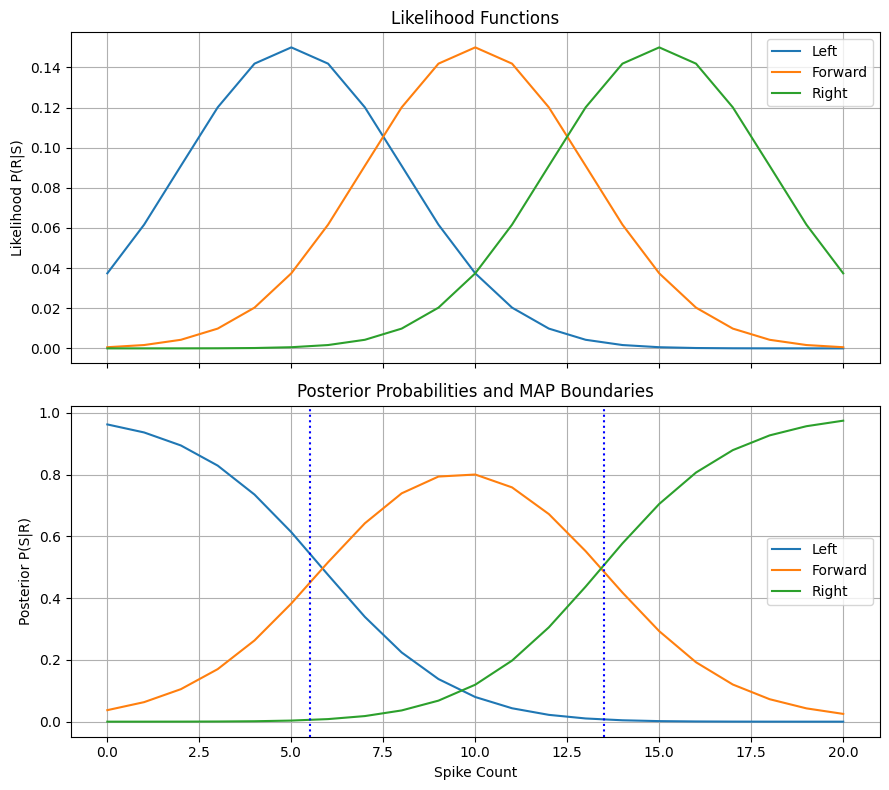

In [7]:
# --- TODO 4: Plotting ---
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Top panel: Likelihoods
axes[0].plot(SPIKE_COUNTS, lik_left, label='Left')
axes[0].plot(SPIKE_COUNTS, lik_forward, label='Forward')
axes[0].plot(SPIKE_COUNTS, lik_right, label='Right')
axes[0].set_ylabel("Likelihood P(R|S)")
axes[0].set_title("Likelihood Functions")
axes[0].legend()
axes[0].grid(True)

# Bottom panel: Posteriors
axes[1].plot(SPIKE_COUNTS, posteriors[:, 0], label='Left')
axes[1].plot(SPIKE_COUNTS, posteriors[:, 1], label='Forward')
axes[1].plot(SPIKE_COUNTS, posteriors[:, 2], label='Right')

# Add decision boundaries (where the MAP choice changes)
for i in range(1, len(map_indices)):
    if map_indices[i] != map_indices[i-1]:
        axes[1].axvline(x=SPIKE_COUNTS[i]-0.5, color='blue', linestyle=':')

axes[1].set_xlabel("Spike Count")
axes[1].set_ylabel("Posterior P(S|R)")
axes[1].set_title("Posterior Probabilities and MAP Boundaries")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()